# Гиперболическая, параболическая и эллиптическая задачи

В отчете решаются три задачи вычислительной математики:

1. линейное одномерное уравнение переноса;
2. двумерное нестационарное уравнение теплопроводности;
3. стационарная задача теплопроводности в квадрате.

Для каждой задачи ниже приведены используемые разностные схемы, численные
эксперименты, графики решений и проверка сходимости по сетке.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.linalg import solve_banded
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "lines.linewidth": 2,
    "font.size": 11,
})

np.set_printoptions(precision=6, suppress=True)


## 1. Линейное одномерное уравнение переноса

Рассматривается задача

$$
\frac{\partial u}{\partial t}+c\frac{\partial u}{\partial x}=0,\qquad c>0.
$$

Расчет ведется на периодическом отрезке $0\le x<1$. При этом точное решение
имеет простой вид:

$$
u(x,t)=u_0((x-ct)\bmod 1).
$$

Используются два начальных профиля: прямоугольный и треугольный импульсы.
Сравниваются четыре схемы:

* схема Куранта--Изаксона--Риса (CIR, первая аппроксимация против потока);
* схема Мак-Кормака;
* гибридная схема Федоренко как переключение между противоточной и
  второй аппроксимацией в гладких областях;
* TVD-схема с ограничителем Ван Лира.

Для всех расчетов число Куранта выбирается близким к $0.45$.


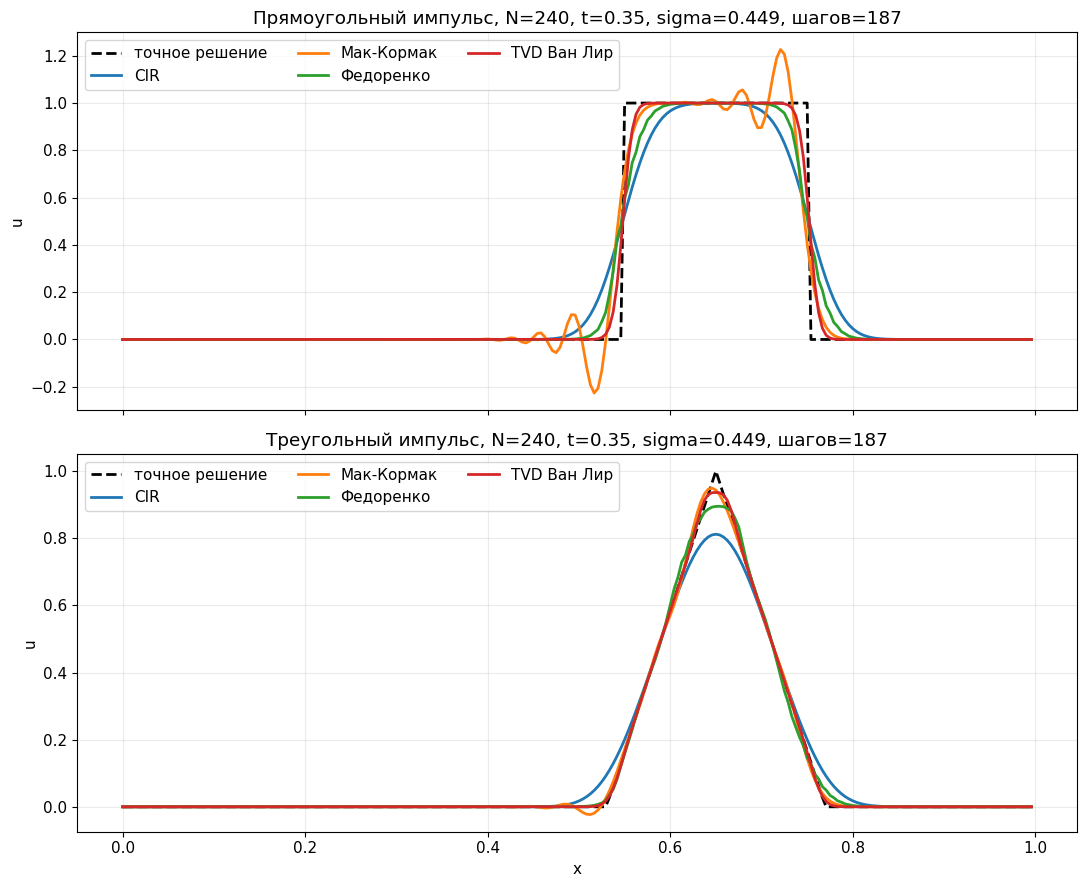

,профиль,схема,N,sigma,L1,L2,Linf,p(L1)
0,Прямоугольный импульс,CIR,80,0.444444,0.078356,0.151260,0.451484,NaN
1,Прямоугольный импульс,CIR,160,0.448000,0.055339,0.127158,0.465429,0.501735
2,Прямоугольный импульс,CIR,320,0.449799,0.039106,0.106958,0.475462,0.500896
3,Прямоугольный импульс,CIR,640,0.449799,0.027666,0.089991,0.482641,0.499266
4,Прямоугольный импульс,Мак-Кормак,80,0.444444,0.061426,0.129965,0.567026,NaN
5,Прямоугольный импульс,Мак-Кормак,160,0.448000,0.041037,0.104632,0.584078,0.581936
6,Прямоугольный импульс,Мак-Кормак,320,0.449799,0.027205,0.084539,0.601622,0.593065
7,Прямоугольный импульс,Мак-Кормак,640,0.449799,0.017978,0.068241,0.615645,0.597631
8,Прямоугольный импульс,Федоренко,80,0.444444,0.050885,0.117228,0.449008,NaN
9,Прямоугольный импульс,Федоренко,160,0.448000,0.035203,0.100399,0.469680,0.531546


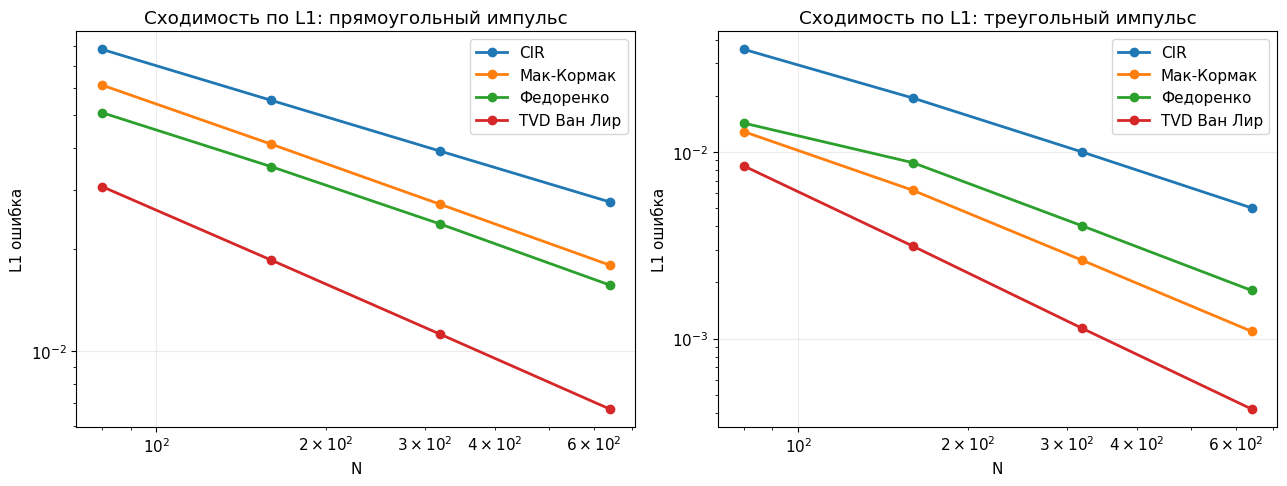

Минимальные L1 ошибки на самой мелкой сетке:


,профиль,схема,L1,L2,Linf
15,Прямоугольный импульс,TVD Ван Лир,0.006735,0.043633,0.432456
11,Прямоугольный импульс,Федоренко,0.015695,0.069447,0.526794
7,Прямоугольный импульс,Мак-Кормак,0.017978,0.068241,0.615645
3,Прямоугольный импульс,CIR,0.027666,0.089991,0.482641
31,Треугольный импульс,TVD Ван Лир,0.000419,0.002157,0.031831
23,Треугольный импульс,Мак-Кормак,0.001094,0.003570,0.029933
27,Треугольный импульс,Федоренко,0.001812,0.006192,0.058493
19,Треугольный импульс,CIR,0.005014,0.015496,0.115277


In [2]:
def rectangular_pulse(x):
    return ((0.20 <= x) & (x <= 0.40)).astype(float)


def triangular_pulse(x):
    return np.maximum(1.0 - np.abs(x - 0.30) / 0.12, 0.0)


def exact_advection(profile, x, c, t):
    return profile((x - c * t) % 1.0)


def cir_step(u, sigma):
    return u - sigma * (u - np.roll(u, 1))


def maccormack_step(u, sigma):
    predictor = u - sigma * (np.roll(u, -1) - u)
    corrector = 0.5 * (u + predictor - sigma * (predictor - np.roll(predictor, 1)))
    return corrector


def high_resolution_step(u, sigma, limiter):
    eps = 1e-14
    du_forward = np.roll(u, -1) - u
    r = (u - np.roll(u, 1)) / (du_forward + eps)
    phi = limiter(r)
    correction = 0.5 * sigma * (1.0 - sigma) * phi * du_forward
    return (
        u
        - sigma * (u - np.roll(u, 1))
        - (correction - np.roll(correction, 1))
    )


def fedorenko_limiter(r):
    # В гладкой монотонной области включается схема второго порядка,
    # около изломов и разрывов остается устойчивая противоточная схема.
    return np.where((r > 0.5) & (r < 2.0), 1.0, 0.0)


def van_leer_limiter(r):
    return (r + np.abs(r)) / (1.0 + np.abs(r))


def fedorenko_step(u, sigma):
    return high_resolution_step(u, sigma, fedorenko_limiter)


def tvd_step(u, sigma):
    return high_resolution_step(u, sigma, van_leer_limiter)


ADVECTION_SCHEMES = {
    "CIR": cir_step,
    "Мак-Кормак": maccormack_step,
    "Федоренко": fedorenko_step,
    "TVD Ван Лир": tvd_step,
}


def solve_advection(profile, n, t_end=0.35, c=1.0, cfl=0.45, stepper=cir_step):
    x = np.arange(n) / n
    h = 1.0 / n
    steps = math.ceil(t_end / (cfl * h / c))
    tau = t_end / steps
    sigma = c * tau / h
    u = profile(x)
    for _ in range(steps):
        u = stepper(u, sigma)
    return x, u, sigma, steps


def error_norms(u, u_exact):
    diff = u - u_exact
    n = len(u)
    h = 1.0 / n
    return {
        "L1": h * np.sum(np.abs(diff)),
        "L2": math.sqrt(h * np.sum(diff**2)),
        "Linf": np.max(np.abs(diff)),
    }


profiles = {
    "Прямоугольный импульс": rectangular_pulse,
    "Треугольный импульс": triangular_pulse,
}

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, (profile_name, profile) in zip(axes, profiles.items()):
    n = 240
    x = np.arange(n) / n
    exact = exact_advection(profile, x, c=1.0, t=0.35)
    ax.plot(x, exact, "k--", label="точное решение")
    for scheme_name, stepper in ADVECTION_SCHEMES.items():
        _, u, sigma, steps = solve_advection(profile, n, stepper=stepper)
        ax.plot(x, u, label=scheme_name)
    ax.set_title(f"{profile_name}, N={n}, t=0.35, sigma={sigma:.3f}, шагов={steps}")
    ax.set_ylabel("u")
    ax.legend(ncol=3)
axes[-1].set_xlabel("x")
plt.tight_layout()
plt.show()


rows = []
grid_sizes = [80, 160, 320, 640]
for profile_name, profile in profiles.items():
    for scheme_name, stepper in ADVECTION_SCHEMES.items():
        previous = None
        for n in grid_sizes:
            x, u, sigma, steps = solve_advection(profile, n, stepper=stepper)
            exact = exact_advection(profile, x, c=1.0, t=0.35)
            norms = error_norms(u, exact)
            order_l1 = np.nan if previous is None else math.log(previous / norms["L1"], 2)
            rows.append({
                "профиль": profile_name,
                "схема": scheme_name,
                "N": n,
                "sigma": sigma,
                "L1": norms["L1"],
                "L2": norms["L2"],
                "Linf": norms["Linf"],
                "p(L1)": order_l1,
            })
            previous = norms["L1"]
advection_errors = pd.DataFrame(rows)
display(advection_errors)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, profile_name in zip(axes, profiles.keys()):
    subset = advection_errors[advection_errors["профиль"] == profile_name]
    for scheme_name in ADVECTION_SCHEMES:
        part = subset[subset["схема"] == scheme_name]
        ax.loglog(part["N"], part["L1"], marker="o", label=scheme_name)
    ax.set_title(f"Сходимость по L1: {profile_name.lower()}")
    ax.set_xlabel("N")
    ax.set_ylabel("L1 ошибка")
    ax.legend()
plt.tight_layout()
plt.show()

print("Минимальные L1 ошибки на самой мелкой сетке:")
display(
    advection_errors[advection_errors["N"] == max(grid_sizes)]
    .sort_values(["профиль", "L1"])
    [["профиль", "схема", "L1", "L2", "Linf"]]
)


### Вывод по уравнению переноса

На прямоугольном импульсе все схемы ограничены низкой фактической
сходимостью, потому что точное решение имеет разрывы. Схема CIR монотонна,
но сильнее всего размазывает фронты. Схема Мак-Кормака лучше сохраняет
гладкие части, но около разрыва дает дисперсионные осцилляции. Гибридная
схема и TVD-схема дают компромисс: второй порядок включается в гладких
областях, а около больших градиентов решение остается монотоннее.

На треугольном импульсе сходимость выше, так как решение непрерывно, хотя в
вершине и на краях импульса остаются изломы.


## 2. Двумерное нестационарное уравнение теплопроводности

Решается задача

$$
\frac{\partial u}{\partial t} =
\frac{\partial^2 u}{\partial x^2}+
\frac{\partial^2 u}{\partial y^2},
\qquad 0\le x,y\le 1,
$$

с граничными условиями

$$
u(t,0,y)=0,\quad u(t,x,0)=2,\quad
u(t,1,y)=1,\quad u(t,x,1)=3.
$$

Угловые значения задаются как среднее двух соседних сторон, поскольку в
формулировке на углах одновременно встречаются два разных граничных
значения.

Используется локально-одномерная схема расщепления:

$$
\frac{\widetilde u-u^n}{\tau}=\Lambda_x\widetilde u,\qquad
\frac{u^{n+1}-\widetilde u}{\tau}=\Lambda_y u^{n+1}.
$$

На каждом полушаге решается набор независимых трехдиагональных систем.


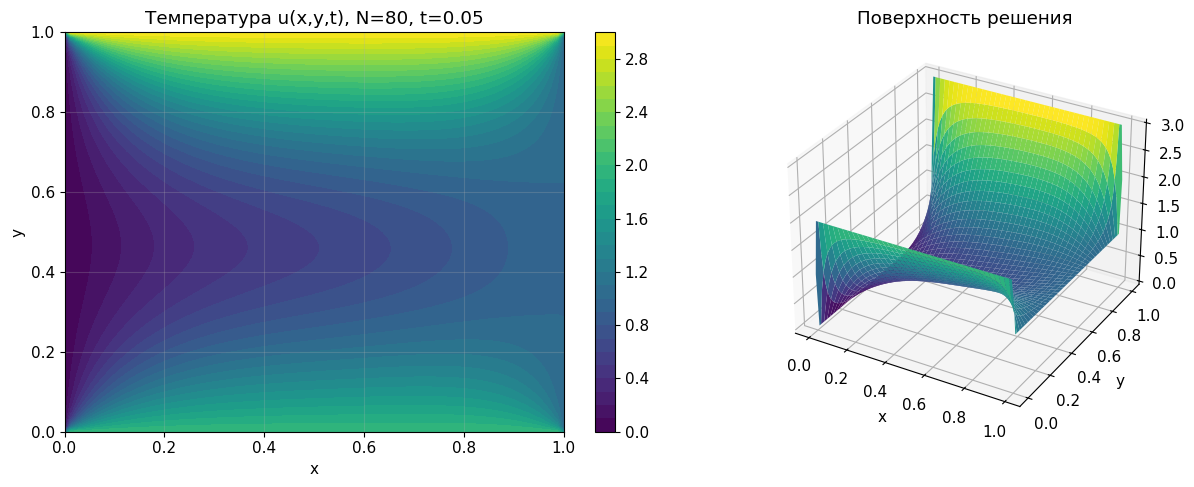

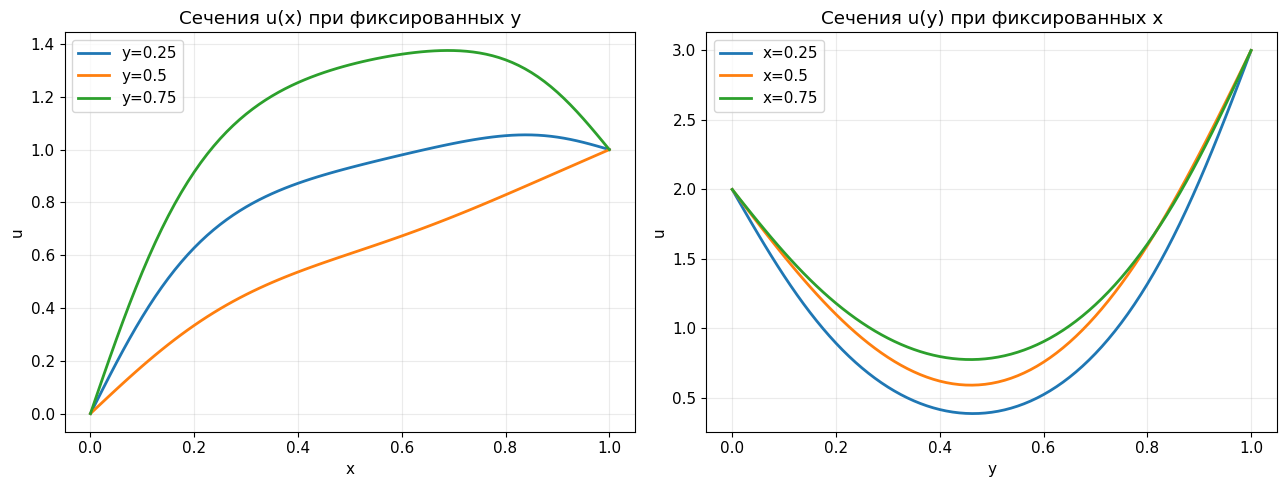

N               20        40        80        160
x    y                                           
0.25 0.25  0.720295  0.717072  0.716212  0.715993
0.50 0.50  0.607418  0.605804  0.605426  0.605333
0.75 0.25  1.040486  1.040896  1.040972  1.040989
     0.75  1.364821  1.365805  1.366007  1.366054

,N,L2 к N=160,Linf к N=160,p(L2)
0,20,0.017151,0.141082,NaN
1,40,0.007970,0.133231,1.105580
2,80,0.003079,0.103896,1.372359


In [3]:
def apply_heat_boundary(u):
    u[0, :] = 0.0
    u[-1, :] = 1.0
    u[:, 0] = 2.0
    u[:, -1] = 3.0
    u[0, 0] = 1.0      # (left + bottom) / 2
    u[-1, 0] = 1.5     # (right + bottom) / 2
    u[-1, -1] = 2.0    # (right + top) / 2
    u[0, -1] = 1.5     # (left + top) / 2
    return u


def band_matrix(size, r):
    ab = np.zeros((3, size))
    ab[0, 1:] = -r
    ab[1, :] = 1.0 + 2.0 * r
    ab[2, :-1] = -r
    return ab


def solve_heat_adi(n, t_end=0.05, tau_factor=0.40):
    h = 1.0 / n
    tau = tau_factor * h * h
    steps = math.ceil(t_end / tau)
    tau = t_end / steps
    r = tau / (h * h)

    x = np.linspace(0.0, 1.0, n + 1)
    y = np.linspace(0.0, 1.0, n + 1)
    u = np.zeros((n + 1, n + 1))
    apply_heat_boundary(u)

    size = n - 1
    ab = band_matrix(size, r)

    for _ in range(steps):
        tilde = np.zeros_like(u)
        apply_heat_boundary(tilde)

        rhs_x = u[1:n, 1:n].copy()
        rhs_x[0, :] += r * tilde[0, 1:n]
        rhs_x[-1, :] += r * tilde[n, 1:n]
        tilde[1:n, 1:n] = solve_banded((1, 1), ab, rhs_x)

        u_next = np.zeros_like(u)
        apply_heat_boundary(u_next)
        rhs_y = tilde[1:n, 1:n].T.copy()
        rhs_y[0, :] += r * u_next[1:n, 0]
        rhs_y[-1, :] += r * u_next[1:n, n]
        u_next[1:n, 1:n] = solve_banded((1, 1), ab, rhs_y).T
        u = u_next

    return x, y, u, tau, steps


def point_values(x, y, u, points):
    rows = []
    for px, py in points:
        i = int(round(px * (len(x) - 1)))
        j = int(round(py * (len(y) - 1)))
        rows.append({"x": px, "y": py, "u": u[i, j]})
    return rows


heat_n = 80
xh, yh, uh, tau_h, steps_h = solve_heat_adi(heat_n)
Xh, Yh = np.meshgrid(xh, yh, indexing="ij")

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1)
cf = ax1.contourf(Xh, Yh, uh, levels=30, cmap="viridis")
ax1.set_title(f"Температура u(x,y,t), N={heat_n}, t=0.05")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(cf, ax=ax1)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(Xh, Yh, uh, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_title("Поверхность решения")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("u")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for yy in [0.25, 0.50, 0.75]:
    j = int(round(yy * heat_n))
    axes[0].plot(xh, uh[:, j], label=f"y={yy}")
axes[0].set_title("Сечения u(x) при фиксированных y")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].legend()

for xx in [0.25, 0.50, 0.75]:
    i = int(round(xx * heat_n))
    axes[1].plot(yh, uh[i, :], label=f"x={xx}")
axes[1].set_title("Сечения u(y) при фиксированных x")
axes[1].set_xlabel("y")
axes[1].set_ylabel("u")
axes[1].legend()
plt.tight_layout()
plt.show()

control_points = [(0.25, 0.25), (0.50, 0.50), (0.75, 0.25), (0.75, 0.75)]
heat_rows = []
heat_solutions = {}
for n in [20, 40, 80, 160]:
    x, y, u, tau, steps = solve_heat_adi(n)
    heat_solutions[n] = (x, y, u, tau, steps)
    for item in point_values(x, y, u, control_points):
        item.update({"N": n, "tau": tau, "steps": steps})
        heat_rows.append(item)
heat_points = pd.DataFrame(heat_rows)
display(heat_points.pivot_table(index=["x", "y"], columns="N", values="u"))

reference_n = 160
reference = heat_solutions[reference_n][2]
conv_rows = []
previous_l2 = None
for n in [20, 40, 80]:
    factor = reference_n // n
    u = heat_solutions[n][2]
    ref_on_grid = reference[::factor, ::factor]
    diff = u - ref_on_grid
    l2 = math.sqrt(np.mean(diff[1:-1, 1:-1] ** 2))
    linf = np.max(np.abs(diff[1:-1, 1:-1]))
    order = np.nan if previous_l2 is None else math.log(previous_l2 / l2, 2)
    conv_rows.append({"N": n, "L2 к N=160": l2, "Linf к N=160": linf, "p(L2)": order})
    previous_l2 = l2
heat_convergence = pd.DataFrame(conv_rows)
display(heat_convergence)


### Вывод по нестационарной теплопроводности

Схема расщепления сводит двумерную задачу к последовательности одномерных
трехдиагональных систем. При уменьшении шага сетки значения в контрольных
точках стабилизируются, а разность с решением на более мелкой сетке
уменьшается. Из-за первого порядка расщепления по времени в расчетах шаг
времени выбран пропорциональным $h^2$, чтобы в таблице в основном была
видна пространственная сходимость.


## 3. Стационарная задача теплопроводности

Решается задача Лапласа в квадрате $0\le x,y\le L$, $L=0.1$ м:

$$
\frac{\partial^2 u}{\partial x^2}+
\frac{\partial^2 u}{\partial y^2}=0.
$$

Стороны квадрата поддерживаются при постоянных температурах:

$$
u|_{AB}=1,\quad u|_{BC}=2,\quad u|_{CD}=3,\quad u|_{DA}=4.
$$

Принята ориентация $A=(0,0)$, $B=(L,0)$, $C=(L,L)$, $D=(0,L)$.
Значит нижняя сторона равна 1, правая 2, верхняя 3, левая 4.
В углах снова используется среднее двух соседних сторон.

Для внутреннего узла используется пятиточечная аппроксимация:

$$
u_{i,j}=\frac14\left(u_{i-1,j}+u_{i+1,j}+u_{i,j-1}+u_{i,j+1}\right).
$$

Сравниваются метод Якоби, метод Зейделя и метод верхней релаксации.
Для квадратной сетки с $N-1$ внутренними узлами в каждом направлении
теоретически

$$
\rho_J=\cos\frac{\pi}{N},\qquad
\rho_{GS}=\rho_J^2,\qquad
\omega_{\mathrm{opt}}=\frac{2}{1+\sqrt{1-\rho_J^2}}.
$$


,метод,N,итераций,последнее изменение,"время, c"
0,Якоби,45,2183,9.987123e-09,0.016299
1,Зейдель,45,1146,9.925971e-09,0.932077
2,"SOR, omega=1.8696",45,149,9.757183e-09,0.121184


,величина,значение
0,rho_J,0.997564
1,rho_GS,0.995134
2,omega_opt,1.869584
3,rho_SOR_opt,0.869584


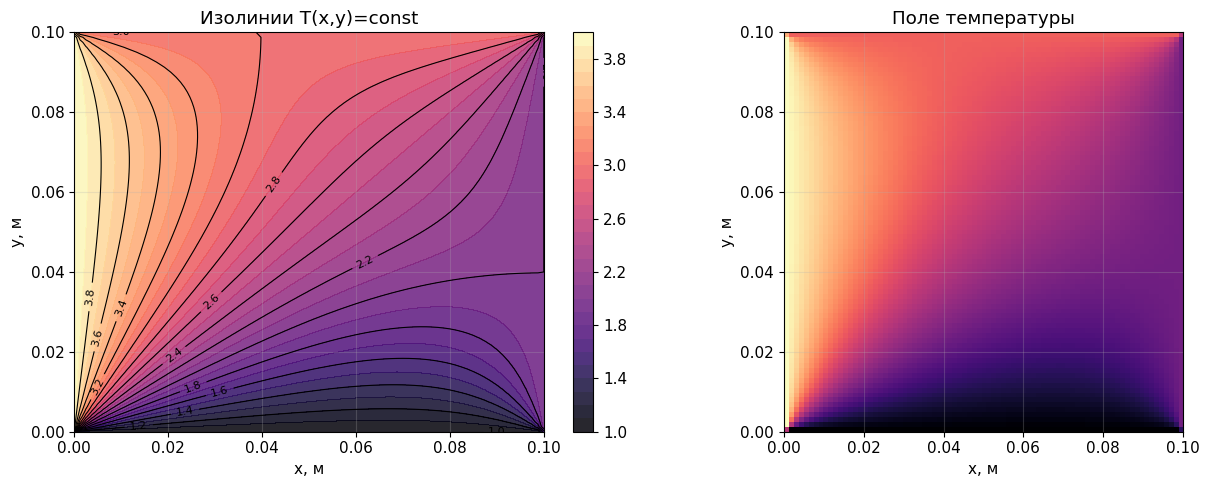

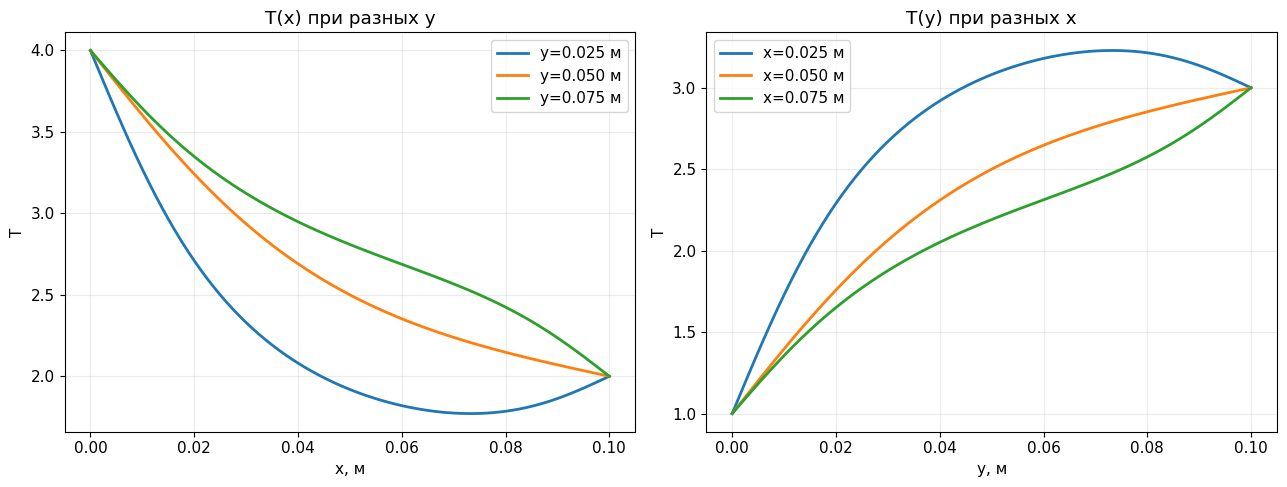

N                 20        40        80        160
x     y                                            
0.025 0.025  2.500000  2.500000  2.500000  2.500000
0.050 0.050  2.500000  2.500000  2.500000  2.500000
0.075 0.025  1.772526  1.772047  1.771927  1.771897
      0.075  2.500000  2.500000  2.500000  2.500000

,N,итераций SOR,L2 к N=160,Linf к N=160,p(L2)
0,20,77,0.002680,0.021067,NaN
1,40,158,0.001230,0.019679,1.123265
2,80,317,0.000467,0.014643,1.398741


In [4]:
def apply_laplace_boundary(u):
    u[:, 0] = 1.0
    u[-1, :] = 2.0
    u[:, -1] = 3.0
    u[0, :] = 4.0
    u[0, 0] = 2.5      # left and bottom
    u[-1, 0] = 1.5     # right and bottom
    u[-1, -1] = 2.5    # right and top
    u[0, -1] = 3.5     # left and top
    return u


def initial_laplace_grid(n):
    u = np.zeros((n + 1, n + 1))
    apply_laplace_boundary(u)
    u[1:n, 1:n] = np.mean([1.0, 2.0, 3.0, 4.0])
    return u


def solve_jacobi(n, tol=1e-8, max_iter=200000):
    u = initial_laplace_grid(n)
    for iteration in range(1, max_iter + 1):
        new_u = u.copy()
        new_u[1:n, 1:n] = 0.25 * (
            u[:-2, 1:n] + u[2:, 1:n] + u[1:n, :-2] + u[1:n, 2:]
        )
        diff = np.max(np.abs(new_u - u))
        u = new_u
        if diff < tol:
            return u, iteration, diff
    return u, max_iter, diff


def solve_gauss_seidel(n, tol=1e-8, max_iter=200000, omega=1.0):
    u = initial_laplace_grid(n)
    for iteration in range(1, max_iter + 1):
        diff = 0.0
        for i in range(1, n):
            for j in range(1, n):
                old = u[i, j]
                gs_value = 0.25 * (u[i - 1, j] + u[i + 1, j] + u[i, j - 1] + u[i, j + 1])
                new_value = old + omega * (gs_value - old)
                local_diff = abs(new_value - old)
                if local_diff > diff:
                    diff = local_diff
                u[i, j] = new_value
        if diff < tol:
            return u, iteration, diff
    return u, max_iter, diff


def optimal_omega(n):
    rho_j = math.cos(math.pi / n)
    return 2.0 / (1.0 + math.sqrt(1.0 - rho_j**2))


compare_n = 45
rho_j = math.cos(math.pi / compare_n)
rho_gs = rho_j**2
omega_opt = optimal_omega(compare_n)

method_rows = []
for name, solver in [
    ("Якоби", lambda: solve_jacobi(compare_n)),
    ("Зейдель", lambda: solve_gauss_seidel(compare_n)),
    (f"SOR, omega={omega_opt:.4f}", lambda: solve_gauss_seidel(compare_n, omega=omega_opt)),
]:
    start = time.perf_counter()
    u_method, iterations, final_update = solver()
    elapsed = time.perf_counter() - start
    method_rows.append({
        "метод": name,
        "N": compare_n,
        "итераций": iterations,
        "последнее изменение": final_update,
        "время, c": elapsed,
    })
methods_table = pd.DataFrame(method_rows)
display(methods_table)

theory_table = pd.DataFrame([
    {"величина": "rho_J", "значение": rho_j},
    {"величина": "rho_GS", "значение": rho_gs},
    {"величина": "omega_opt", "значение": omega_opt},
    {"величина": "rho_SOR_opt", "значение": omega_opt - 1.0},
])
display(theory_table)

laplace_solutions = {}
for n in [20, 40, 80, 160]:
    omega = optimal_omega(n)
    u, iterations, final_update = solve_gauss_seidel(n, tol=1e-9, omega=omega)
    laplace_solutions[n] = (u, iterations, final_update, omega)

L = 0.1
n_plot = 80
u_plot = laplace_solutions[n_plot][0]
xs = np.linspace(0.0, L, n_plot + 1)
ys = np.linspace(0.0, L, n_plot + 1)
X, Y = np.meshgrid(xs, ys, indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
contour = axes[0].contour(X, Y, u_plot, levels=18, colors="black", linewidths=0.8)
axes[0].clabel(contour, inline=True, fontsize=8)
cf = axes[0].contourf(X, Y, u_plot, levels=30, cmap="magma", alpha=0.85)
axes[0].set_title("Изолинии T(x,y)=const")
axes[0].set_xlabel("x, м")
axes[0].set_ylabel("y, м")
fig.colorbar(cf, ax=axes[0])

axes[1].imshow(
    u_plot.T,
    origin="lower",
    extent=[0, L, 0, L],
    cmap="magma",
    aspect="equal",
)
axes[1].set_title("Поле температуры")
axes[1].set_xlabel("x, м")
axes[1].set_ylabel("y, м")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for yy in [0.025, 0.050, 0.075]:
    j = int(round(yy / L * n_plot))
    axes[0].plot(xs, u_plot[:, j], label=f"y={yy:.3f} м")
axes[0].set_title("T(x) при разных y")
axes[0].set_xlabel("x, м")
axes[0].set_ylabel("T")
axes[0].legend()

for xx in [0.025, 0.050, 0.075]:
    i = int(round(xx / L * n_plot))
    axes[1].plot(ys, u_plot[i, :], label=f"x={xx:.3f} м")
axes[1].set_title("T(y) при разных x")
axes[1].set_xlabel("y, м")
axes[1].set_ylabel("T")
axes[1].legend()
plt.tight_layout()
plt.show()

stat_points = [(0.025, 0.025), (0.050, 0.050), (0.075, 0.025), (0.075, 0.075)]
stat_rows = []
for n, (u, iterations, final_update, omega) in laplace_solutions.items():
    for px, py in stat_points:
        i = int(round(px / L * n))
        j = int(round(py / L * n))
        stat_rows.append({
            "N": n,
            "x": px,
            "y": py,
            "T": u[i, j],
            "итераций SOR": iterations,
            "omega": omega,
        })
stat_points_table = pd.DataFrame(stat_rows)
display(stat_points_table.pivot_table(index=["x", "y"], columns="N", values="T"))

ref_n = 160
ref = laplace_solutions[ref_n][0]
stat_conv_rows = []
previous_l2 = None
for n in [20, 40, 80]:
    factor = ref_n // n
    u = laplace_solutions[n][0]
    ref_on_grid = ref[::factor, ::factor]
    diff = u - ref_on_grid
    l2 = math.sqrt(np.mean(diff[1:-1, 1:-1] ** 2))
    linf = np.max(np.abs(diff[1:-1, 1:-1]))
    order = np.nan if previous_l2 is None else math.log(previous_l2 / l2, 2)
    stat_conv_rows.append({
        "N": n,
        "итераций SOR": laplace_solutions[n][1],
        "L2 к N=160": l2,
        "Linf к N=160": linf,
        "p(L2)": order,
    })
    previous_l2 = l2
display(pd.DataFrame(stat_conv_rows))


### Итоговые выводы

1. Для уравнения переноса схемы высокого разрешения дают наиболее
аккуратное решение на разрывных и кусочно-гладких профилях: они меньше
размазывают фронты, чем CIR, и подавляют осцилляции лучше, чем схема
Мак-Кормака.

2. Для двумерной нестационарной теплопроводности схема расщепления удобна
тем, что каждый шаг сводится к двум сериям одномерных трехдиагональных
систем. Таблицы по контрольным точкам и нормам подтверждают стабилизацию
решения при измельчении сетки.

3. Для стационарной задачи метод Якоби сходится медленнее всего, метод
Зейделя заметно быстрее, а SOR с близким к оптимальному параметром
релаксации требует на порядок меньше итераций. Это согласуется с
теоретическими оценками спектральных радиусов.
